In [1]:
import mysql.connector
from mysql.connector import errorcode
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
config = {    
  'user': 'root',
  'password': '*',  
  'host': 'localhost',
  'database': 'basketball_stats'
}

DB_NAME = 'basketball_stats' 

print("Connection parameters defined.")

Connection parameters defined.


In [3]:
try:
    
    cnxn = mysql.connector.connect(**config)
    cursor = cnxn.cursor()
    print("✅ Connected to basketball_stats database.")


    # cnxn.commit()
    # print("✅ SQL script executed successfully.")

except mysql.connector.Error as err:
    print(f"❌ Connection or execution error: {err}")

finally:
    if 'cnxn' in locals() and cnxn.is_connected():
        cursor.close()
        cnxn.close()
        print("✅ Connection closed.")

✅ Connected to basketball_stats database.
✅ Connection closed.


In [4]:
#بخش اول
try:
    
    with mysql.connector.connect(**config) as cnxn:
        query = """

        select
            mc.year as season,
            p.player_id,
            p.player_name,
            p.height_cm,
            'Michael Jordan Trophy' as group_label
        from mvp_candidates mc
        join players p on p.player_id = mc.player_id
        where
            mc.year between 2020 and 2024
            and mc.ws is not null
            and p.height_cm is not null

        union all

        
        select
            ps.season,
            p.player_id,
            p.player_name,
            p.height_cm,
            'Top 50 by  rank' as group_label
        from player_stats ps
        join players p on p.player_id = ps.player_id
        where
            ps.season between 2020 and 2024
            and ps.rank <= 50 and p.height_cm is not null;
            """
        
        df1 = pd.read_sql(query, cnxn)
        display(df1)

except mysql.connector.Error as err:
    print(f"❌ Error: {err}")


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_9884\898110108.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(query, cnxn)


,season,player_id,player_name,height_cm,group_label
0,2020,antetgi01,giannis antetokounmpo,211.0,Michael Jordan Trophy
1,2020,butleji01,jimmy butler,201.0,Michael Jordan Trophy
2,2020,davisan02,anthony davis,208.0,Michael Jordan Trophy
3,2020,doncilu01,luka donÃ¤ÂiÃ¤Â,198.0,Michael Jordan Trophy
4,2020,hardeja01,james harden,196.0,Michael Jordan Trophy
...,...,...,...,...,...
306,2024,wembavi01,victor wembanyama,221.0,Top 50 by rank
307,2024,whiteco01,coby white,196.0,Top 50 by rank
308,2024,willija06,jalen williams,198.0,Top 50 by rank
309,2024,willizi01,zion williamson,198.0,Top 50 by rank


c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

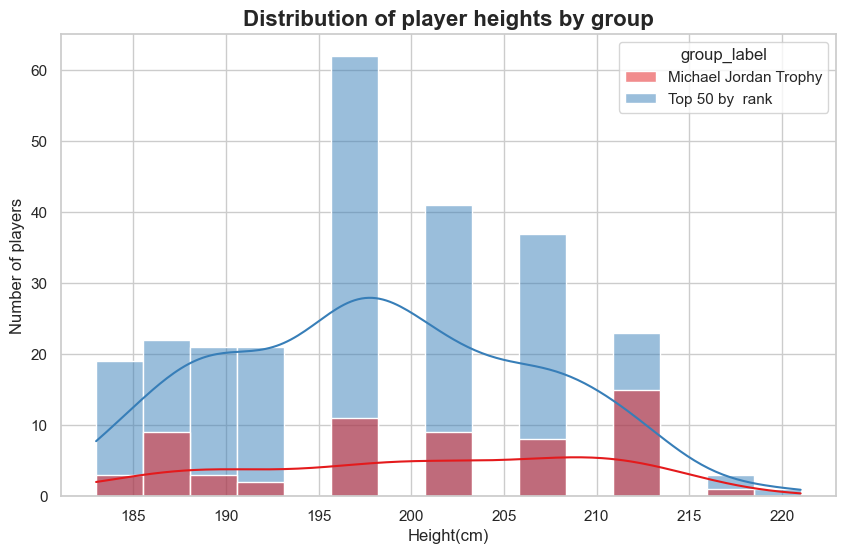

In [5]:
# هیستوگرام بخش اول

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.histplot(data=df1, x="height_cm", hue= "group_label",kde=True, bins=15,palette="Set1")

ax.set_title("Distribution of player heights by group", fontsize=16, weight='bold')
ax.set_xlabel("Height(cm)", fontsize=12)
ax.set_ylabel("Number of players", fontsize=12)

plt.show()


c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

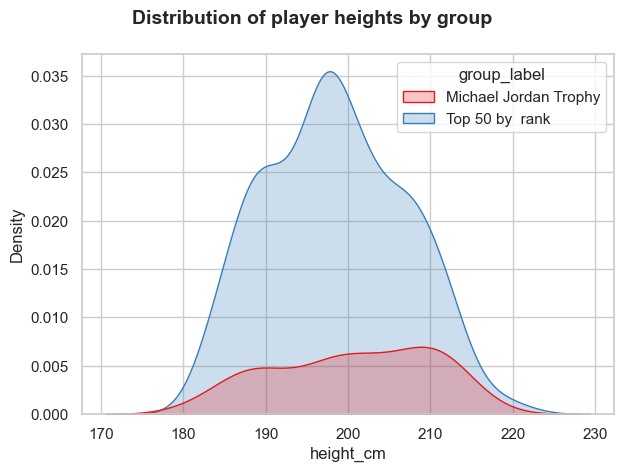

In [6]:
#kde
sns.kdeplot(data=df1, x="height_cm", hue= "group_label", palette="Set1",  fill=True)

plt.suptitle("Distribution of player heights by group", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [21]:
# بخش دوم
# بررسی فقط ۱۵ رکورد فصلی برتر در کل دوره (فصل‌های ۲۰۲۴ و ۲۰۲۵ با هم) .
try:
    
    with mysql.connector.connect(**config) as cnxn:
        query = """
        select
            r.season,
            p.player_id,
            p.player_name,
            p.experience,
            p.height_cm, 'Champion team players' as group_label
        from season_stats s
        join team_lookup t on s.champion_name = t.team_name
        join rosters r on r.team_id = t.team_id and r.season = s.season
        join players p on p.player_id = r.player_id
        where
            s.season in (2024, 2025)
            and p.experience is not null
            and p.height_cm is not null

        union all

        select
            a.season,
            p.player_id,
            p.player_name,
            p.experience,
            p.height_cm,'Top 15 by win shares' as group_label
        from (
            select player_id, season
            from advanced_stats
            where season in (2024, 2025)
            and win_shares is not null
            order by win_shares desc
            limit 15
        )as top15
        join players p on p.player_id = top15.player_id
        join advanced_stats a on a.player_id = top15.player_id and a.season = top15.season
        where p.experience is not null and p.height_cm is not null;
        """
        
        df2 = pd.read_sql(query, cnxn)
        display(df2)

except mysql.connector.Error as err:
    print(f"❌ Error: {err}")


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_10372\1079465158.py:43: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(query, cnxn)


,season,player_id,player_name,experience,height_cm,group_label
0,2024,bantoda01,dalano banton,4.0,206.0,Champion team players
1,2024,brissos01,oshae brissett,6.0,201.0,Champion team players
2,2024,brownja02,jaylen brown,9.0,198.0,Champion team players
3,2024,davisjd01,jd davison,3.0,185.0,Champion team players
4,2024,hausesa01,sam hauser,4.0,203.0,Champion team players
5,2024,holidjr01,jrue holiday,16.0,193.0,Champion team players
6,2024,horfoal01,al horford,18.0,206.0,Champion team players
7,2024,kornelu01,luke kornet,8.0,218.0,Champion team players
8,2024,mykhasv01,svi mykhailiuk,7.0,201.0,Champion team players
9,2024,peterdr01,drew peterson,2.0,206.0,Champion team players


c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

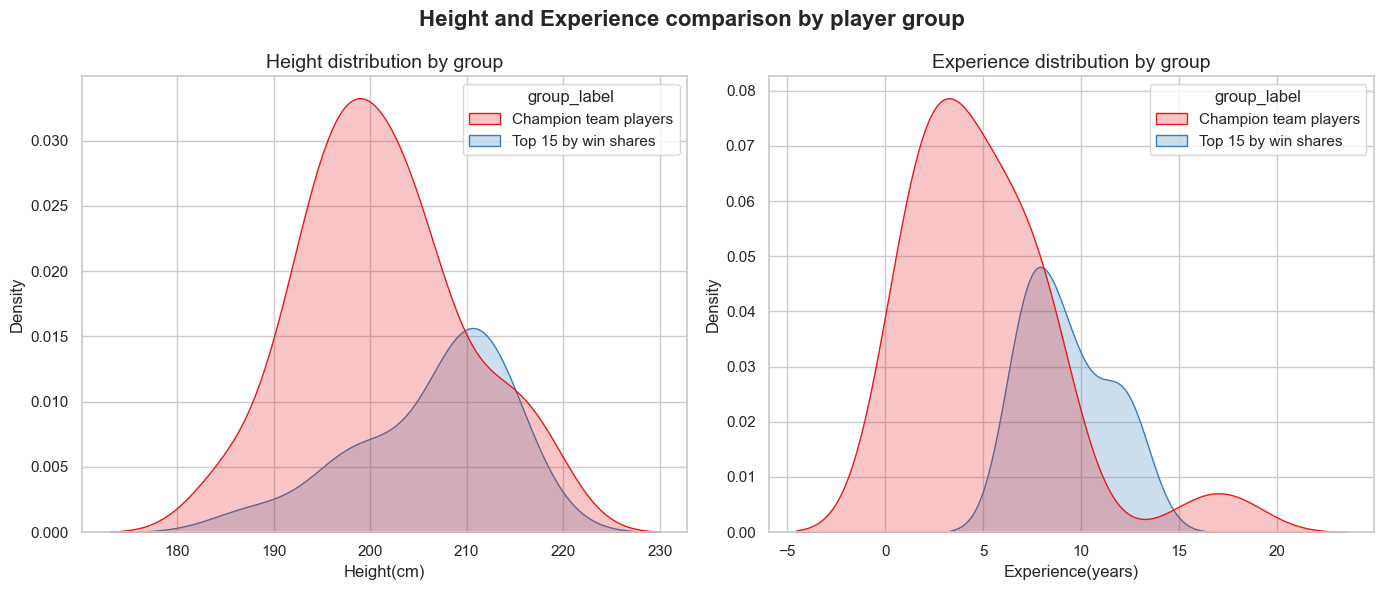

In [58]:
# توزیع تجربه- قد  هیستوگرام بخش دوم

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KDE plot for height
sns.kdeplot( data=df2, x="height_cm", hue="group_label",  palette="Set1",  fill=True, ax=axes[0])
axes[0].set_title("Height distribution by group", fontsize=14)
axes[0].set_xlabel("Height(cm)", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)

# KDE plot for experience
sns.kdeplot( data=df2, x="experience",hue="group_label", palette="Set1", fill=True, ax=axes[1] )
axes[1].set_title("Experience distribution by group", fontsize=14)
axes[1].set_xlabel("Experience(years)", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)


plt.suptitle("Height and Experience comparison by player group", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

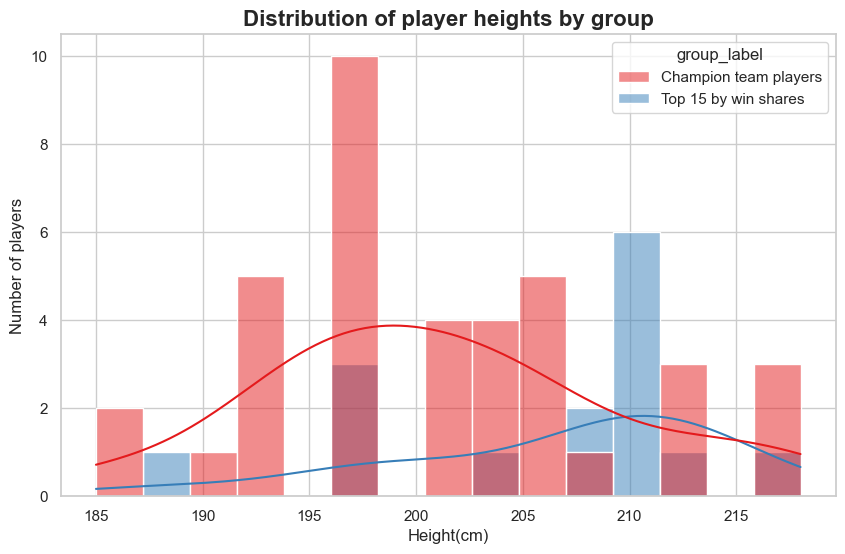

In [52]:
# هیستوگرام بخش دوم- توزیع قد
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.histplot( data=df2, x="height_cm",hue="group_label", kde=True, bins=15, palette="Set1")

ax.set_title("Distribution of player heights by group", fontsize=16, weight='bold')
ax.set_xlabel("Height(cm)", fontsize=12)
ax.set_ylabel("Number of players", fontsize=12)

plt.show()


c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

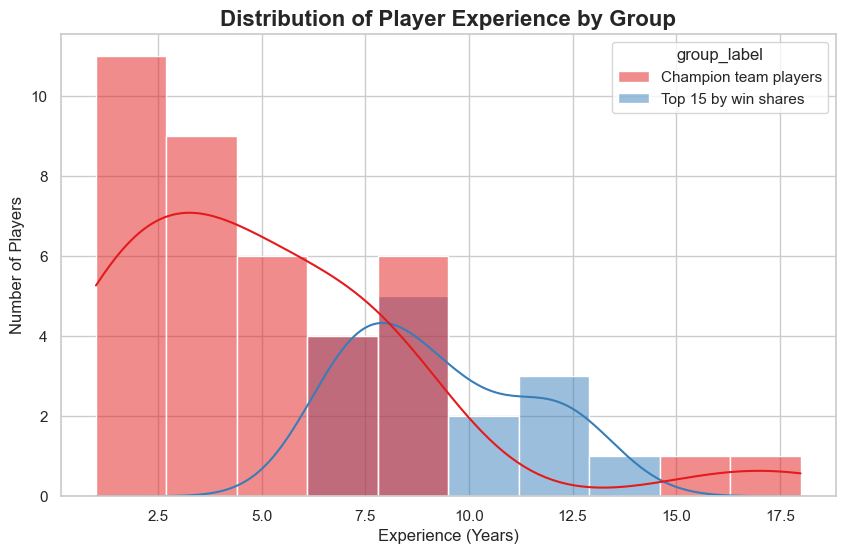

In [53]:
# هیستوگرام بخش دوم- توزیع تجربه
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.histplot( data=df2, x="experience", hue="group_label", kde=True, bins=10, palette="Set1")

ax.set_title("Distribution of Player Experience by Group", fontsize=16, weight='bold')
ax.set_xlabel("Experience (Years)", fontsize=12)
ax.set_ylabel("Number of Players", fontsize=12)

plt.show()


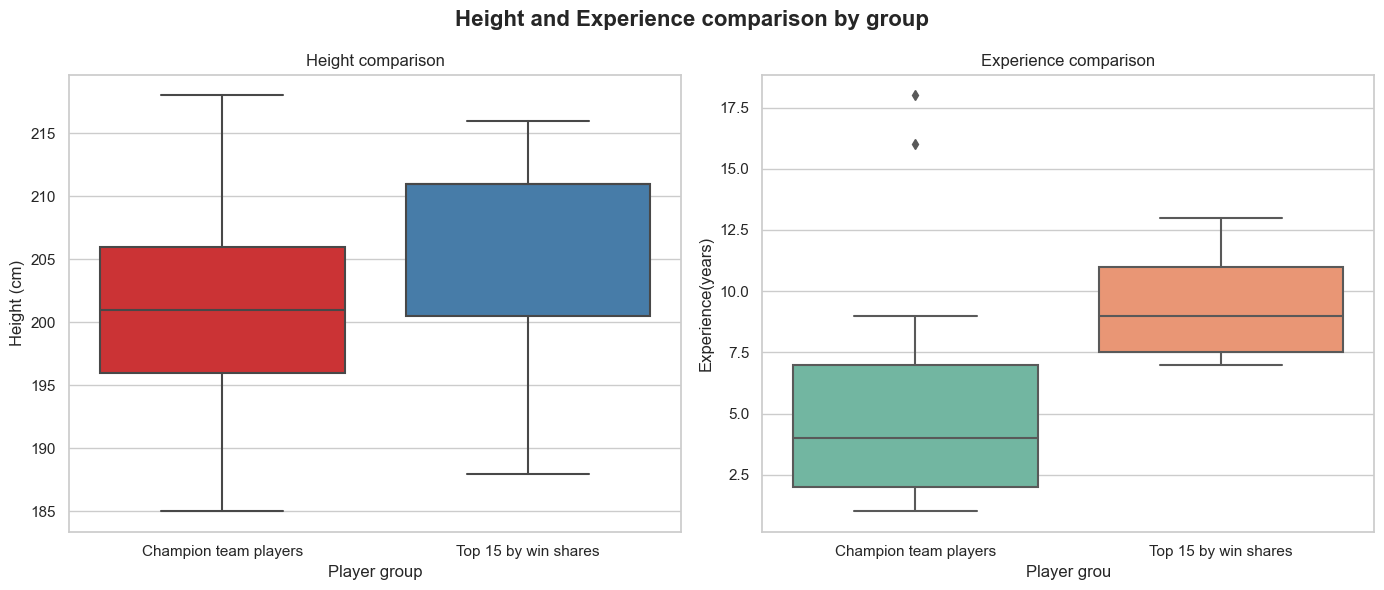

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x="group_label", y="height_cm", data=df2, palette="Set1", ax=axes[0])
axes[0].set_title("Height comparison", fontsize=12)
axes[0].set_xlabel("Player group")
axes[0].set_ylabel("Height (cm)")

sns.boxplot(x="group_label", y="experience", data=df2, palette="Set2", ax=axes[1])
axes[1].set_title("Experience comparison", fontsize=12)
axes[1].set_xlabel("Player grou")
axes[1].set_ylabel("Experience(years)")

plt.suptitle("Height and Experience comparison by group", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


این بخش پاسخ سوال دومه ولی به تفکیک فصل


In [23]:
# بخش دوم - به تفکیک فصل
try:
    
    with mysql.connector.connect(**config) as cnxn:
        query = """
        with top15 as (
            select
                player_id,
                season,
                win_shares,
                row_number() over (partition by season order by win_shares desc) as rn
            from advanced_stats
            where season in (2024, 2025)
            and win_shares is not null
        )

        select
            r.season,
            p.player_id,
            p.player_name,
            p.experience,
            p.height_cm,
            'Champion team players' as group_label
        from season_stats s
        join team_lookup t on s.champion_name = t.team_name
        join rosters r on r.team_id = t.team_id and r.season = s.season
        join players p on p.player_id = r.player_id
        where s.season in (2024, 2025)
            and p.experience is not null
            and p.height_cm is not null

        union all

        select
            a.season,
            p.player_id,
            p.player_name,
            p.experience,
            p.height_cm,
            'Top 15 by win shares' as group_label
        from top15
        join players p on p.player_id = top15.player_id
        join advanced_stats a on a.player_id = top15.player_id and a.season = top15.season
        where top15.rn <= 15
            and p.experience is not null
            and p.height_cm is not null;

        """
        
        df22 = pd.read_sql(query, cnxn)
        display(df22)

except mysql.connector.Error as err:
    print(f"❌ Error: {err}")

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_10372\3531769864.py:50: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df22 = pd.read_sql(query, cnxn)


,season,player_id,player_name,experience,height_cm,group_label
0,2024,bantoda01,dalano banton,4.0,206.0,Champion team players
1,2024,brissos01,oshae brissett,6.0,201.0,Champion team players
2,2024,brownja02,jaylen brown,9.0,198.0,Champion team players
3,2024,davisjd01,jd davison,3.0,185.0,Champion team players
4,2024,hausesa01,sam hauser,4.0,203.0,Champion team players
...,...,...,...,...,...,...
63,2025,durenja01,jalen duren,3.0,208.0,Top 15 by win shares
64,2025,hartjo01,josh hart,8.0,193.0,Top 15 by win shares
65,2025,mobleev01,evan mobley,4.0,211.0,Top 15 by win shares
66,2025,butleji01,jimmy butler,14.0,201.0,Top 15 by win shares


c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

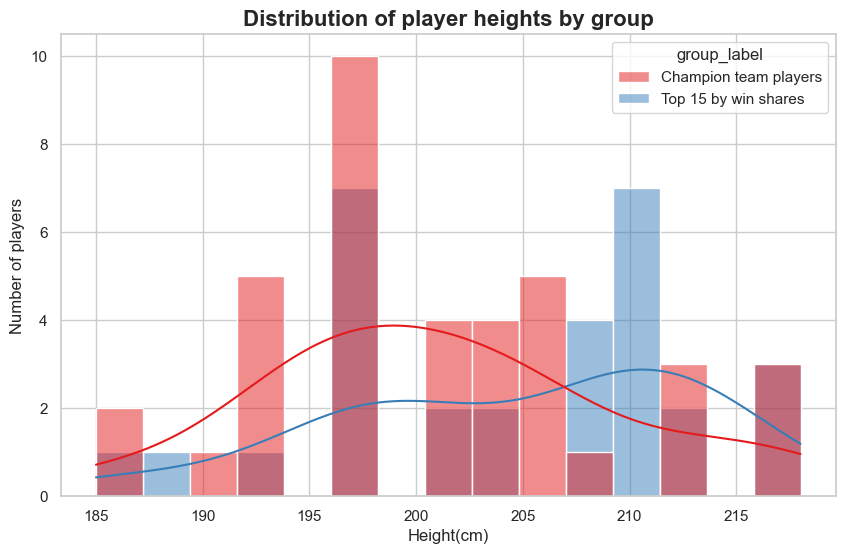

In [55]:
# توزیع قد- به تفکیک فصل هیستوگرام بخش دوم
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.histplot( data=df22, x="height_cm",hue="group_label", kde=True, bins=15, palette="Set1")

ax.set_title("Distribution of player heights by group", fontsize=16, weight='bold')
ax.set_xlabel("Height(cm)", fontsize=12)
ax.set_ylabel("Number of players", fontsize=12)

plt.show()


c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

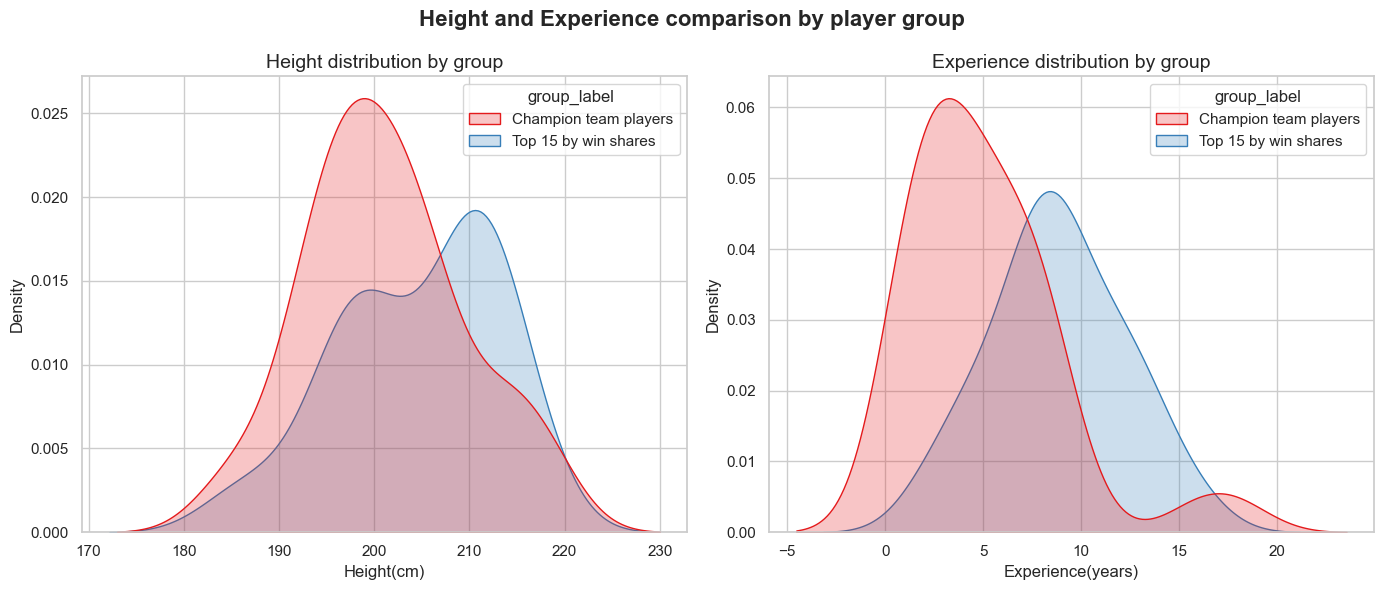

In [ ]:
# توزیع تجربه- قد به تفکیک فصل هیستوگرام بخش دوم

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


sns.kdeplot( data=df22, x="height_cm", hue="group_label",  palette="Set1",  fill=True, ax=axes[0])
axes[0].set_title("Height distribution by group", fontsize=14)
axes[0].set_xlabel("Height(cm)", fontsize=12)
axes[0].set_ylabel("Density", fontsize=12)


sns.kdeplot( data=df22, x="experience",hue="group_label", palette="Set1", fill=True, ax=axes[1] )
axes[1].set_title("Experience distribution by group", fontsize=14)
axes[1].set_xlabel("Experience(years)", fontsize=12)
axes[1].set_ylabel("Density", fontsize=12)


plt.suptitle("Height and Experience comparison by player group", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()


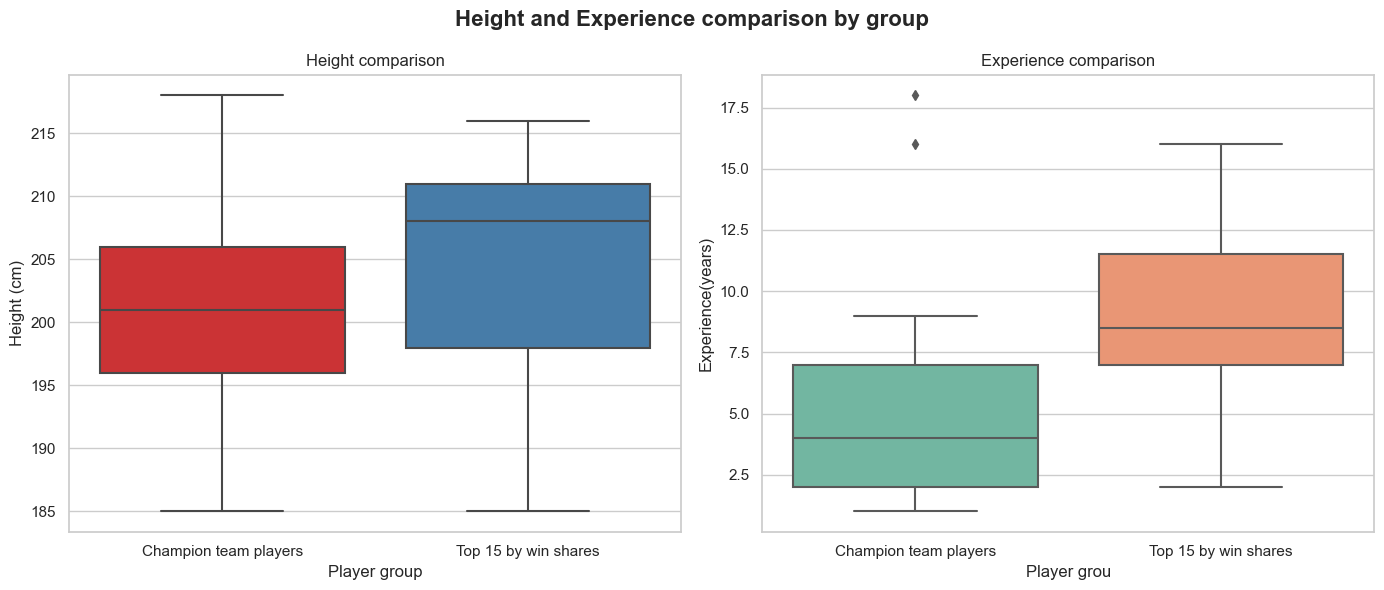

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x="group_label", y="height_cm", data=df22, palette="Set1", ax=axes[0])
axes[0].set_title("Height comparison", fontsize=12)
axes[0].set_xlabel("Player group")
axes[0].set_ylabel("Height (cm)")

sns.boxplot(x="group_label", y="experience", data=df22, palette="Set2", ax=axes[1])
axes[1].set_title("Experience comparison", fontsize=12)
axes[1].set_xlabel("Player grou")
axes[1].set_ylabel("Experience(years)")

plt.suptitle("Height and Experience comparison by group", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()